# Spatial Multi-Path-Redundancy Gold-QCN Corpus — *prevalence gate* (demo)

This demo accompanies the **spatial multi-path-redundant gold-QCN corpus**, an
**a-priori, descriptive prevalence gate**: it measures how often a spatial-QA
corpus contains *deductively redundant* query pairs — the spatial analog of the
temporal `N*` gate — without running any closure, LLM, or derived precision/recall.
The whole pipeline is **deterministic and $0** (no API calls).

**The core idea.** From each published spatial scene we reconstruct a *gold
relation-graph* (nodes = objects/blocks, edges = stated spatial relations split
into **RCC-8** `{DC,EC,PO,EQ,TPP,NTPP,TPPI,NTPPI}` vs **cardinal-direction**
`{N/S/E/W + diagonals + near/far + front/behind}`), then for a **held-out query
edge** `(src, dst)` we compute structural metrics with `networkx`:

| metric | meaning |
|---|---|
| `hop_length` | shortest-path length between `src` and `dst` |
| `num_edge_disjoint_paths` | max edge-disjoint paths (Menger / max-flow) |
| `cyclomatic_number` | `E − V + C` on the union of those paths |
| `deduction_required` | the query pair is **not** a directly-stated edge |
| `genuine_multipath_with_bite` | deduction-required **AND** ≥2 edge-disjoint paths each len ≥2 (the spatial `N*` analog) |
| `genuine_multipath_with_bite_tight` | additionally ≥2 of those paths are **short** (len ≤4) — the *deductively meaningful* redundancy |

**GO / NO-GO bands** (tight-bite fraction of deduction-required queries):
`≥10%` = **general**, `5–10%` = **useful module**, `<5%` = **niche**.
The recommended venue **SpaRP-PS1 (SpaRTUN)** scores **27.4% — general** on the full corpus.

**What this notebook does.** It loads a curated subset of the *emitted* SpaRP-PS1
rows (each row already carries the gold graph), then **re-runs the exact core
pipeline** — `scene_graphs` → `query_metrics_on` → prevalence aggregation — and
verifies the recomputed metrics match the stored annotations bit-for-bit. This is
the same `graphmetrics.py` / `algebra.py` / aggregation code as the original
`data.py`, just split into cells with the raw-download/acquisition step replaced
by loading the published rows.

In [1]:
# --- Dependencies (Colab-safe install pattern) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# networkx + matplotlib are pre-installed on Colab. On Colab we must NOT reinstall
# them (corrupts loaded C-extensions); locally we install Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('networkx==3.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- imports (from the original data.py, trimmed to the demo core) ---
import json
import statistics
from collections import Counter, defaultdict

import networkx as nx          # the engine behind the structural multi-path metrics
import matplotlib.pyplot as plt

In [3]:
# --- Data loading: GitHub URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-4/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

# the demo subset keeps the same {metadata, datasets} shape as the full corpus
corpus = data["datasets"][0]
print("artifact :", data["metadata"]["artifact"])
print("note     :", data["metadata"]["note"])
print("dataset  :", corpus["dataset"])
print("rows     :", len(corpus["examples"]))

# peek at one emitted row: input=story text, output=JSON gold-graph, metadata_* fields
ex0 = corpus["examples"][0]
print("\n--- example[0] ---")
print("input  :", ex0["input"][:200], "...")
print("doc_id :", ex0["metadata_doc_id"], "| deduction_required:",
      ex0["metadata_deduction_required"], "| bite:",
      ex0["metadata_genuine_multipath_with_bite"])

artifact : SPATIAL multi-path-redundant gold-QCN corpus (iter-4 dataset_1)
note     : DEMO SUBSET: 80 diverse SpaRP-PS1 (SpaRTUN) rows from the full 2316, stratified to preserve the rare genuine-multipath-with-bite signal. Full-corpus prevalence for this venue: 27.4% tight bite (general band).
dataset  : SpaRP-PS1
rows     : 80

--- example[0] ---
input  : Two boxes, named one and two exist in the image. Box one covers a medium yellow apple. In box two there is this box. Box two has a medium orange apple which is to the south of a medium yellow apple an ...
doc_id : SpaRP-PS1_test_0 | deduction_required: True | bite: True


## Config

The only tunable knob for this demo is **`MAX_EXAMPLES`** — how many of the loaded
rows to process (the analog of `--limit-scenes` in the original `data.py`). It
starts at the absolute minimum and is scaled up below. The structural-metric
*definitions* (root-node id, ≥2-disjoint-paths, short-path ≤4) are part of the
method and live unchanged in the core cells.

In [5]:
# --- CONFIG: tunable demo parameters ---
MAX_EXAMPLES = 80     # how many loaded rows to process. MIN useful = 5; full subset = 80.
                      # original full run processes the entire corpus (2316 SpaRP-PS1 rows).

# applicability-band thresholds (fraction of deduction-required queries with bite)
BAND_GENERAL = 0.10   # >=10%  -> general
BAND_USEFUL  = 0.05   # 5-10%  -> useful module ; <5% -> niche

## 1. Structural multi-path-redundancy metrics (`graphmetrics.py`)

This is the substantive core, copied **verbatim** from the artifact's
`src/graphmetrics.py`. For a held-out query pair `(src, dst)` on the undirected
projection `G` of the *stated* relation edges it computes hop-length, the number
of edge-disjoint paths (Menger / max-flow), the cyclomatic number, and the
`genuine_multipath_with_bite` flags. The world/image-container root node (`'-1'`)
is excluded from the primary graph because "object X is inside the image" composes
to the universal relation and carries no deductive bite.

In [6]:
# ============ src/graphmetrics.py (verbatim) ============
ROOT_IDS = {"-1"}  # world/image container node(s) excluded from the primary graph.


def build_undirected(edges, drop_nodes=frozenset()):
    """edges: iterable of (src,dst) stated relation pairs (relation labels are
    collapsed -- one undirected edge per related node pair).  Self-loops and
    edges touching drop_nodes are skipped.  Returns a simple nx.Graph."""
    g = nx.Graph()
    for s, d in edges:
        if s == d or s in drop_nodes or d in drop_nodes:
            continue
        g.add_edge(s, d)
    return g


def _edge_disjoint_paths(g, src, dst):
    if src not in g or dst not in g or src == dst:
        return []
    if not nx.has_path(g, src, dst):
        return []
    try:
        return [list(p) for p in nx.edge_disjoint_paths(g, src, dst)]
    except nx.NetworkXNoPath:
        return []


def _cyclomatic(g, paths):
    """mu = E - V + C on the subgraph induced by the union of `paths`."""
    sub = nx.Graph()
    for p in paths:
        for a, b in zip(p[:-1], p[1:]):
            sub.add_edge(a, b)
    if sub.number_of_nodes() == 0:
        return 0
    E = sub.number_of_edges()
    V = sub.number_of_nodes()
    C = nx.number_connected_components(sub)
    return E - V + C


def scene_graphs(edges):
    """Build the (root-included, root-excluded) graphs ONCE per scene so a scene
    with many enumerated queries does not rebuild them per query."""
    g_full = build_undirected(edges)
    g = build_undirected(edges, drop_nodes=ROOT_IDS)
    return g_full, g


def query_metrics_on(g_full, g, src, dst, stated_pairs):
    """Structural metric bundle for query (src,dst) on prebuilt graphs."""
    directly_stated = frozenset({src, dst}) in stated_pairs
    deduction_required = not directly_stated

    paths = _edge_disjoint_paths(g, src, dst)
    paths_full = _edge_disjoint_paths(g_full, src, dst)
    n_disjoint = len(paths)
    n_disjoint_with_root = len(paths_full)
    n_len_ge2 = sum(1 for p in paths if (len(p) - 1) >= 2)

    if src in g and dst in g and nx.has_path(g, src, dst):
        hop = nx.shortest_path_length(g, src, dst)
    else:
        hop = -1  # query endpoints not connected via non-root stated edges

    mu = _cyclomatic(g, paths)

    # Path-length profile of the edge-disjoint set (networkx returns A maximal
    # edge-disjoint set via max-flow -- shorter augmenting paths first but NOT
    # provably length-minimal, so these lengths are a near-tight upper bound).
    path_lens = sorted(len(p) - 1 for p in paths)
    n_short = sum(1 for ln in path_lens if 2 <= ln <= 4)

    bite = bool(deduction_required and n_disjoint >= 2 and n_len_ge2 >= 2)
    # TIGHT redundancy: >=2 disjoint constraining paths that are BOTH short
    # (len<=4) -> the cross-path intersection is far likelier to actually narrow
    # (long cardinal-composition paths tend to compose toward the universal rel).
    bite_tight = bool(deduction_required and n_short >= 2)

    return {
        "hop_length": int(hop),
        "num_edge_disjoint_paths": int(n_disjoint),
        "num_edge_disjoint_paths_with_root": int(n_disjoint_with_root),
        "num_disjoint_paths_len_ge2": int(n_len_ge2),
        "disjoint_path_lengths": path_lens,
        "second_path_length": int(path_lens[1]) if len(path_lens) >= 2 else -1,
        "cyclomatic_number": int(mu),
        "deduction_required": bool(deduction_required),
        "genuine_multipath_with_bite": bite,
        "genuine_multipath_with_bite_tight": bite_tight,
        "connected": bool(hop >= 1),
        "n_nodes_noroot": int(g.number_of_nodes()),
        "n_edges_noroot": int(g.number_of_edges()),
    }

## 2. Relation → canonical-algebra mapping (`algebra.py`)

Copied **verbatim** from `src/algebra.py`. Every native spatial relation token is
mapped into one of two calculi: **RCC-8** (mereotopological, engine-validated) or
**cardinal_direction** (directional / distance / out-of-2D-CDC depth). Tokens that
cannot be placed return `algebra='unmapped'` so the vocabulary ledger stays honest.

In [7]:
# ============ src/algebra.py :: map_relation (verbatim) ============
# RCC-8 base symbols (canonical upper-case), keyed by every native spelling we see.
RCC8_SYMBOLS = {"DC", "EC", "PO", "EQ", "TPP", "NTPP", "TPPI", "NTPPI"}

# SpaRP symbolic_context uses lower-case RCC-8 tokens verbatim.
_RCC8_TOKEN = {
    "dc": "DC", "ec": "EC", "po": "PO", "eq": "EQ",
    "tpp": "TPP", "ntpp": "NTPP", "tppi": "TPPI", "ntppi": "NTPPI",
}

# Verbalised topological phrases (SpaRP `targets`, SpartQA `spatial_indicator`,
# SpartQA `rel_with_block`) -> RCC-8.  Verified against SpaRP `target_choices`.
_RCC8_VERBAL = {
    "outside": "DC", "disconnected": "DC", "disconnected from": "DC",
    "outside and touching": "EC", "touching": "EC", "touching the bottom edge of": "TPP",
    "partially overlapping": "PO", "overlapping": "EQ", "equal": "EQ",
    "inside and touching": "TPP", "inside": "NTPP", "in": "NTPP",
    "contains and touches": "TPPI", "contains": "NTPPI", "has": "NTPPI",
    "cover": "TPPI", "covers": "TPPI", "covered by": "TPP",
    "touching the bottom edge of": "TPP", "touching the top edge of": "TPP",
    "touching the left edge of": "TPP", "touching the right edge of": "TPP",
    "touching the bottom of": "TPP", "touching the top of": "TPP",
}

# Directional / distance words -> cardinal-direction-calculus tile names.
_DIR = {
    "left": "W", "right": "E", "above": "N", "below": "S",
    "north": "N", "south": "S", "east": "E", "west": "W",
    "northeast": "NE", "northwest": "NW", "southeast": "SE", "southwest": "SW",
    "upper-left": "NW", "upper-right": "NE", "lower-left": "SW", "lower-right": "SE",
    "top-left": "NW", "top-right": "NE", "bottom-left": "SW", "bottom-right": "SE",
    "upper": "N", "lower": "S", "top": "N", "bottom": "S", "up": "N", "down": "S",
}
# Distance (not a direction) -- tagged distance algebra, recorded under cardinal_direction family.
_DIST = {"near": "NEAR", "near to": "NEAR", "close": "NEAR", "far": "FAR", "far from": "FAR"}
# 3-D depth -- NOT part of standard 2-D CDC; flagged out_of_cdc.
_DEPTH = {"front": "FRONT", "in front": "FRONT", "in front of": "FRONT",
          "behind": "BEHIND", "back": "BEHIND"}


def map_relation(native: str) -> dict:
    """Map ONE native relation token/phrase to {algebra, canonical, flags}."""
    t = native.strip().lower()
    if t in _RCC8_TOKEN:
        return {"algebra": "rcc8", "canonical": _RCC8_TOKEN[t], "subtype": "topological"}
    if t in _RCC8_VERBAL:
        return {"algebra": "rcc8", "canonical": _RCC8_VERBAL[t], "subtype": "topological"}
    if t in _DIR:
        return {"algebra": "cardinal_direction", "canonical": _DIR[t], "subtype": "direction"}
    if t in _DIST:
        return {"algebra": "cardinal_direction", "canonical": _DIST[t], "subtype": "distance"}
    if t in _DEPTH:
        return {"algebra": "cardinal_direction", "canonical": _DEPTH[t],
                "subtype": "depth_out_of_cdc"}
    # heuristic fallback: any "...touching...edge..." phrasing => inside & touching (TPP)
    if "touch" in t and "edge" in t:
        return {"algebra": "rcc8", "canonical": "TPP", "subtype": "topological"}
    return {"algebra": "unmapped", "canonical": None, "subtype": "unmapped"}

## 3. Re-run the pipeline on the gold graphs (mirrors `score_corpus`)

Each emitted row carries its reconstructed gold graph (`nodes`, `edges`,
`query_edge`). Here we rebuild the scene graphs and **recompute** the structural
metrics with the verbatim core above — exactly what `score_corpus` does in
`data.py` — and assert the recomputed bundle matches the stored annotation
bit-for-bit (the pipeline is deterministic). `stated_pairs` is the set of
node-pairs that appear as stated edges; the query is `deduction_required` when it
is *not* among them.

In [8]:
# Build `records` (one per (scene,query) row) by recomputing metrics from the gold graph.
examples = corpus["examples"][:MAX_EXAMPLES]
records = []
n_match = 0
for ex in examples:
    out = json.loads(ex["output"])           # {nodes, edges, query_edge}
    edges = out["edges"]
    q = out["query_edge"]
    edge_pairs = [(e["src"], e["dst"]) for e in edges]
    stated_pairs = {frozenset({e["src"], e["dst"]}) for e in edges}

    g_full, g = scene_graphs(edge_pairs)                       # build once per scene
    m = query_metrics_on(g_full, g, q["src"], q["dst"], stated_pairs)  # recompute

    # verify recomputed == stored annotation (deterministic pipeline)
    stored = {k: q[k] for k in m}
    if m == stored:
        n_match += 1

    records.append({
        "doc_id": ex["metadata_doc_id"],
        "text": ex["input"],
        "is_templated": ex["metadata_is_templated"],
        "is_natural_text": ex["metadata_is_natural_text"],
        "edges": edges,
        "query": q,
        "metrics": m,
    })

print(f"processed {len(records)} rows")
print(f"recomputed metrics match stored annotation: {n_match}/{len(records)}")

processed 80 rows
recomputed metrics match stored annotation: 80/80


## 4. Prevalence aggregation (`_band` + `prevalence_row`)

The corpus-level prevalence row, copied from `data.py` (band thresholds wired to
the config cell). It reports the fraction of deduction-required queries that carry
genuine multipath bite — the number the GO/NO-GO decision is based on — plus the
tight-bite fraction, connectivity, hop-length stats, and document-length stats.

In [9]:
THREE_K = 3000  # project ~3000-char document target


def _band(frac):
    if frac >= BAND_GENERAL:
        return "general (>=10%)"
    if frac >= BAND_USEFUL:
        return "useful_module (5-10%)"
    return "niche (<5%)"


def prevalence_row(name, records, scenes):
    n = len(records)
    if n == 0:
        return None
    ded = [r for r in records if r["metrics"]["deduction_required"]]
    bite = [r for r in records if r["metrics"]["genuine_multipath_with_bite"]]
    bite_t = [r for r in records if r["metrics"]["genuine_multipath_with_bite_tight"]]
    ge2 = [r for r in records if r["metrics"]["num_edge_disjoint_paths"] >= 2]
    conn = [r for r in records if r["metrics"]["connected"]]
    hops = [r["metrics"]["hop_length"] for r in conn]
    mus = [r["metrics"]["cyclomatic_number"] for r in records]
    cyc_or_long = [r for r in records
                   if r["metrics"]["hop_length"] >= 3 or r["metrics"]["cyclomatic_number"] >= 1]
    n_ded = len(ded)
    frac_bite_ded = (len(bite) / n_ded) if n_ded else 0.0
    clen = [len(s["text"]) for s in scenes]
    reaches = sum(1 for c in clen if c >= THREE_K)
    is_tmpl = scenes[0]["is_templated"] if scenes else None
    is_nat = scenes[0]["is_natural_text"] if scenes else None
    return {
        "corpus": name,
        "is_templated": is_tmpl, "is_natural_text": is_nat,
        "n_scenes": len(scenes),
        "n_evaluable_queries": n,
        "frac_deduction_required": round(n_ded / n, 4),
        "frac_ge2_edge_disjoint_paths": round(len(ge2) / n, 4),
        "n_genuine_multipath_with_bite": len(bite),
        "frac_bite_of_all_queries": round(len(bite) / n, 4),
        "frac_bite_of_deduction_required": round(frac_bite_ded, 4),
        "applicability_band_(on_deduction_required)": _band(frac_bite_ded),
        "n_bite_tight": len(bite_t),
        "frac_bite_tight_of_deduction_required": round(len(bite_t) / n_ded, 4) if n_ded else 0.0,
        "band_tight_(on_deduction_required)": _band((len(bite_t) / n_ded) if n_ded else 0.0),
        "frac_connected": round(len(conn) / n, 4),
        "mean_hop_length": round(statistics.mean(hops), 3) if hops else None,
        "median_hop_length": statistics.median(hops) if hops else None,
        "mean_cyclomatic_number": round(statistics.mean(mus), 3) if mus else 0.0,
        "frac_hop_ge3_or_cyclic": round(len(cyc_or_long) / n, 4),
        "doc_char_len_mean": round(statistics.mean(clen), 1) if clen else 0,
        "doc_char_len_median": int(statistics.median(clen)) if clen else 0,
        "doc_char_len_max": max(clen) if clen else 0,
        "frac_reaching_3000_char_target": round(reaches / len(clen), 4) if clen else 0.0,
    }


# `scenes` = unique documents (one row may share a doc with another query)
_seen, scenes = set(), []
for r in records:
    if r["doc_id"] in _seen:
        continue
    _seen.add(r["doc_id"])
    scenes.append({"text": r["text"], "is_templated": r["is_templated"],
                   "is_natural_text": r["is_natural_text"]})

prevalence = prevalence_row("SpaRP-PS1 (demo subset)", records, scenes)
print(json.dumps(prevalence, indent=1))

{
 "corpus": "SpaRP-PS1 (demo subset)",
 "is_templated": true,
 "is_natural_text": false,
 "n_scenes": 80,
 "n_evaluable_queries": 80,
 "frac_deduction_required": 0.8125,
 "frac_ge2_edge_disjoint_paths": 0.6625,
 "n_genuine_multipath_with_bite": 40,
 "frac_bite_of_all_queries": 0.5,
 "frac_bite_of_deduction_required": 0.6154,
 "applicability_band_(on_deduction_required)": "general (>=10%)",
 "n_bite_tight": 40,
 "frac_bite_tight_of_deduction_required": 0.6154,
 "band_tight_(on_deduction_required)": "general (>=10%)",
 "frac_connected": 1.0,
 "mean_hop_length": 1.988,
 "median_hop_length": 2.0,
 "mean_cyclomatic_number": 0.912,
 "frac_hop_ge3_or_cyclic": 0.8,
 "doc_char_len_mean": 505,
 "doc_char_len_median": 489,
 "doc_char_len_max": 955,
 "frac_reaching_3000_char_target": 0.0
}


## 5. Relation-vocabulary coverage ledger (condensed `vocab_ledger`)

A condensed version of `data.py`'s `vocab_ledger`: re-map every native relation
token on the demo subset with `map_relation` and tally RCC-8 vs cardinal-direction
vs unmapped. Coverage = 0 unmapped after mapping (the card's honesty check).

In [10]:
rcc8, cdc, dist, depth, unmapped = Counter(), Counter(), Counter(), Counter(), Counter()
per_corpus = {"rcc8": 0, "cardinal_direction": 0, "mixed": 0, "unmapped": 0, "n_edges": 0}
for r in records:
    for e in r["edges"]:
        per_corpus["n_edges"] += 1
        per_corpus[e.get("algebra", "unmapped")] += 1          # per-edge tag (authoritative)
        for nat in e["native_relation"]:                       # token-level re-map
            mm = map_relation(str(nat))
            key = str(nat).lower().strip()
            if mm["algebra"] == "rcc8":
                rcc8[key] += 1
            elif mm["algebra"] == "cardinal_direction":
                (dist if mm["subtype"] == "distance"
                 else depth if mm["subtype"] == "depth_out_of_cdc"
                 else cdc)[key] += 1
            else:
                unmapped[key] += 1

print("per-edge algebra counts:", dict(per_corpus))
print("RCC-8 tokens            :", dict(rcc8.most_common()))
print("cardinal_direction      :", dict(cdc.most_common()))
print("distance                :", dict(dist.most_common()))
print("depth (out-of-CDC)      :", dict(depth.most_common()))
print("UNMAPPED tokens         :", dict(unmapped.most_common()), "(0 = full coverage)")

per-edge algebra counts: {'rcc8': 589, 'cardinal_direction': 267, 'mixed': 39, 'unmapped': 0, 'n_edges': 895}
RCC-8 tokens            : {'ntpp': 227, 'ntppi': 177, 'tpp': 77, 'tppi': 69, 'ec': 53, 'dc': 24, 'po': 1}
cardinal_direction      : {'above': 125, 'below': 100, 'left': 34, 'right': 17}
distance                : {'far': 16, 'near': 12}
depth (out-of-CDC)      : {'front': 21, 'behind': 11}
UNMAPPED tokens         : {} (0 = full coverage)


## 6. Results: prevalence summary, an auditable trace, and distributions

We (a) print the demo prevalence row next to the full-corpus reference, (b) show a
**human-auditable trace** for one `genuine_multipath_with_bite` query — the two
edge-disjoint reasoning paths that make the query deductively redundant — and (c)
plot the hop-length and edge-disjoint-path distributions and the bite breakdown.

> Note: the demo subset is **stratified to over-sample the rare bite signal** so the
> trace and plots are illustrative, so its `frac_bite_*` is intentionally higher
> than the full-corpus 27.4% reference printed alongside.

metric                                   demo subset     full corpus
--------------------------------------------------------------------
n_evaluable_queries                               80            2316
frac_deduction_required                       0.8125          0.4983
n_genuine_multipath_with_bite                     40             316
frac_bite_of_deduction_required               0.6154          0.2738
band (on deduction-required)         general (>=10%) general (>=10%)
frac_bite_tight_of_deduction_req              0.6154          0.2738
mean_hop_length                                1.988           1.674
mean_cyclomatic_number                         0.912           0.812

HUMAN-AUDITABLE TRACE  (genuine_multipath_with_bite)
story    : Two boxes, named one and two exist in the image. Box one covers a medium yellow apple. In box two there is this box. Box two has a medium orange apple which is to the south of a medium yellow apple and touches another me ...
query    : 1x2 -> 1x

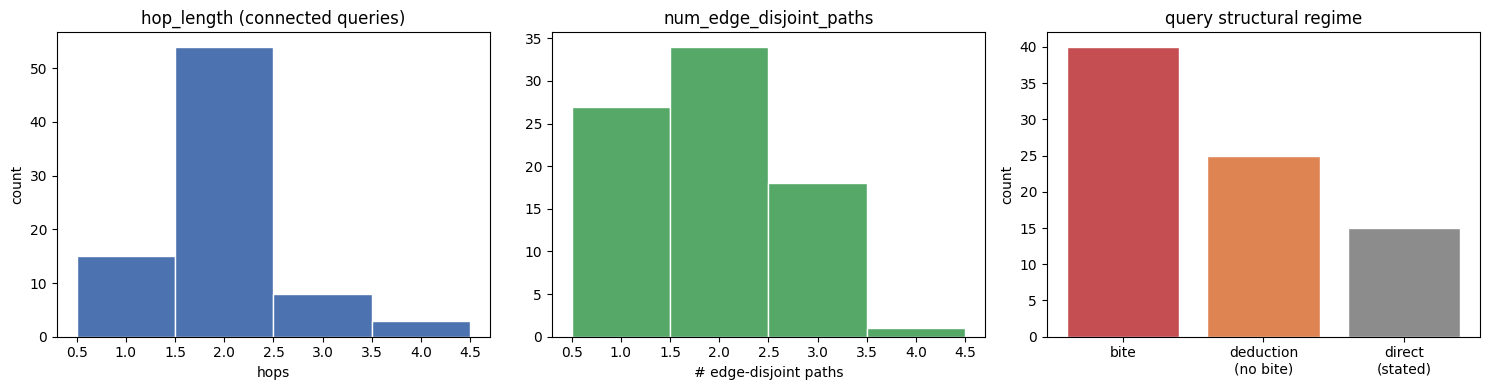

In [11]:
# (a) prevalence summary vs full-corpus reference -----------------------------
ref = data["metadata"].get("full_corpus_prevalence_row_SpaRP_PS1", {})
rows = [
    ("n_evaluable_queries",                 prevalence["n_evaluable_queries"], ref.get("n_evaluable_queries")),
    ("frac_deduction_required",             prevalence["frac_deduction_required"], ref.get("frac_deduction_required")),
    ("n_genuine_multipath_with_bite",       prevalence["n_genuine_multipath_with_bite"], ref.get("n_genuine_multipath_with_bite")),
    ("frac_bite_of_deduction_required",     prevalence["frac_bite_of_deduction_required"], ref.get("frac_bite_of_deduction_required")),
    ("band (on deduction-required)",        prevalence["applicability_band_(on_deduction_required)"], ref.get("applicability_band_(on_deduction_required)")),
    ("frac_bite_tight_of_deduction_req",    prevalence["frac_bite_tight_of_deduction_required"], ref.get("frac_bite_tight_of_deduction_required")),
    ("mean_hop_length",                     prevalence["mean_hop_length"], ref.get("mean_hop_length")),
    ("mean_cyclomatic_number",              prevalence["mean_cyclomatic_number"], ref.get("mean_cyclomatic_number")),
]
print(f"{'metric':<36}{'demo subset':>16}{'full corpus':>16}")
print("-" * 68)
for name, dv, rv in rows:
    print(f"{name:<36}{str(dv):>16}{str(rv):>16}")

# (b) human-auditable trace for one bite query --------------------------------
trace = next((r for r in records if r["metrics"]["genuine_multipath_with_bite"]), None)
if trace:
    q = trace["query"]
    g_full, g = scene_graphs([(e["src"], e["dst"]) for e in trace["edges"]])
    paths = list(nx.edge_disjoint_paths(g, q["src"], q["dst"]))
    print("\n" + "=" * 68)
    print("HUMAN-AUDITABLE TRACE  (genuine_multipath_with_bite)")
    print("=" * 68)
    print("story    :", trace["text"][:220], "...")
    print("query    :", q["src"], "->", q["dst"],
          "| gold:", q.get("gold_canonical"), f"({q.get('gold_algebra')})")
    print(f"hop_length={trace['metrics']['hop_length']}  "
          f"edge_disjoint_paths={trace['metrics']['num_edge_disjoint_paths']}  "
          f"cyclomatic={trace['metrics']['cyclomatic_number']}")
    for i, p in enumerate(paths, 1):
        print(f"  reasoning path {i}: " + "  ->  ".join(p))

# (c) distribution plots ------------------------------------------------------
hops = [r["metrics"]["hop_length"] for r in records if r["metrics"]["connected"]]
ndp  = [r["metrics"]["num_edge_disjoint_paths"] for r in records]
n_bite      = sum(1 for r in records if r["metrics"]["genuine_multipath_with_bite"])
n_ded_only  = sum(1 for r in records if r["metrics"]["deduction_required"]
                  and not r["metrics"]["genuine_multipath_with_bite"])
n_direct    = sum(1 for r in records if not r["metrics"]["deduction_required"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(hops, bins=range(min(hops), max(hops) + 2), align="left",
           color="#4C72B0", edgecolor="white")
ax[0].set_title("hop_length (connected queries)"); ax[0].set_xlabel("hops"); ax[0].set_ylabel("count")
ax[1].hist(ndp, bins=range(min(ndp), max(ndp) + 2), align="left",
           color="#55A868", edgecolor="white")
ax[1].set_title("num_edge_disjoint_paths"); ax[1].set_xlabel("# edge-disjoint paths")
ax[2].bar(["bite", "deduction\n(no bite)", "direct\n(stated)"],
          [n_bite, n_ded_only, n_direct],
          color=["#C44E52", "#DD8452", "#8C8C8C"], edgecolor="white")
ax[2].set_title("query structural regime"); ax[2].set_ylabel("count")
plt.tight_layout()
plt.show()